In [1]:
import rasterio

in_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

with rasterio.open(in_fp) as src:
    print("width:", src.width)
    print("height:", src.height)
    print("bands:", src.count)
    print("dtype:", src.dtypes)
    print("crs:", src.crs)
    print("res:", src.res)

import sys
import numpy
from osgeo import gdal

print(sys.executable)
print(numpy.__version__)
print(gdal.VersionInfo())

width: 130000
height: 140000
bands: 1
dtype: ('float32',)
crs: EPSG:3035
res: (30.0, 30.0)
/mnt/dss_project/lmandl/anaconda3/envs/backcasting/bin/python
1.26.4
3110400


In [2]:
import sys
import numpy
from osgeo import gdal

print(sys.executable)
print(numpy.__version__)
print(gdal.VersionInfo())

/mnt/dss_project/lmandl/anaconda3/envs/backcasting/bin/python
1.26.4
3110400


In [3]:
import math
import subprocess
import sys

in_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
tmp_binary_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/tmp_binary_gt07.tif"
out_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_8conn_5ha_1105.tif"

threshold = 0.8
pixel_size = 30
mmu_ha = 5
connectivity = 8

min_pixels = math.ceil((mmu_ha * 10000) / (pixel_size * pixel_size))
print("Minimum pixels for MMU:", min_pixels)

calc_cmd = [
    sys.executable, "-m", "osgeo_utils.gdal_calc",
    "-A", in_fp,
    "--outfile", tmp_binary_fp,
    f"--calc=(A>{threshold})",
    "--type=Byte",
    "--NoDataValue=0",
    "--co=COMPRESS=LZW",
    "--co=TILED=YES",
    "--co=BIGTIFF=YES",
    "--overwrite"
]
subprocess.run(calc_cmd, check=True)

sieve_cmd = [
    sys.executable, "-m", "osgeo_utils.gdal_sieve",
    "-st", str(min_pixels),
    "-8" if connectivity == 8 else "-4",
    tmp_binary_fp,
    out_fp
]
subprocess.run(sieve_cmd, check=True)

print("Done.")
print("Output:", out_fp)

Minimum pixels for MMU: 56
0...10...20...30...40...50...60...70...80...90...100 - done in 00:07:03.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:04:25.
Done.
Output: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_8conn_5ha_1105.tif


In [10]:
import os
import math
import subprocess
import sys
import rasterio
import numpy as np

in_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
tmp_binary_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/tmp_binary_gt08_TRUE_0_1.tif"
out_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"

threshold = 0.8
pixel_size = 30
mmu_ha = 5
min_pixels = math.ceil((mmu_ha * 10000) / (pixel_size * pixel_size))

print("Minimum pixels:", min_pixels)

for fp in [tmp_binary_fp, out_fp]:
    if os.path.exists(fp):
        os.remove(fp)

# ------------------------------------------------------------
# 1) Create a real 0/1 raster
# ------------------------------------------------------------
with rasterio.open(in_fp) as src:
    profile = src.profile.copy()
    nodata_in = src.nodata

    profile.update(
        dtype="uint8",
        count=1,
        nodata=None,
        compress="lzw",
        tiled=True,
        BIGTIFF="YES"
    )

    with rasterio.open(tmp_binary_fp, "w", **profile) as dst:
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)

            # Everything > threshold becomes 1, everything else becomes 0
            out = np.where(arr > threshold, 1, 0).astype("uint8")

            # If the original input has NoData, force those pixels to 0 as well
            if nodata_in is not None:
                out[arr == nodata_in] = 0

            dst.write(out, 1, window=window)

print("Binary raster written:", tmp_binary_fp)

# ------------------------------------------------------------
# 2) Sieve small 1-patches smaller than 5 ha
# ------------------------------------------------------------
sieve_cmd = [
    sys.executable, "-m", "osgeo_utils.gdal_sieve",
    "-st", str(min_pixels),
    "-4",
    "-nomask",
    tmp_binary_fp,
    out_fp
]

print(" ".join(sieve_cmd))
subprocess.run(sieve_cmd, check=True)

# Remove NoData flag from output, just to be safe
subprocess.run(["gdal_edit.py", "-unsetnodata", out_fp], check=True)

print("Done.")
print("Output:", out_fp)

Minimum pixels: 56
Binary raster written: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/tmp_binary_gt08_TRUE_0_1.tif
/mnt/dss_project/lmandl/anaconda3/envs/backcasting/bin/python -m osgeo_utils.gdal_sieve -st 56 -4 -nomask /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/tmp_binary_gt08_TRUE_0_1.tif /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif
0...10...20...30...40...50...60...70...80...90...100 - done in 00:05:34.
Done.
Output: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif


In [16]:
import subprocess

in_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
out_nodata_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif"

subprocess.run([
    "gdal_translate",
    "-a_nodata", "0",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    "-co", "BIGTIFF=YES",
    in_fp,
    out_nodata_fp
], check=True)

subprocess.run(["gdalinfo", out_nodata_fp], check=True)

Input file size is 130000, 140000
0...10...20...30...40...50...60...70...80...90...100 - done in 00:02:12.
Driver: GTiff/GeoTIFF
Files: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif
Size is 130000, 140000
Coordinate System is:
PROJCRS["ETRS89-extended / LAEA Europe",
    BASEGEOGCRS["ETRS89",
        ENSEMBLE["European Terrestrial Reference System 1989 ensemble",
            MEMBER["European Terrestrial Reference Frame 1989"],
            MEMBER["European Terrestrial Reference Frame 1990"],
            MEMBER["European Terrestrial Reference Frame 1991"],
            MEMBER["European Terrestrial Reference Frame 1992"],
            MEMBER["European Terrestrial Reference Frame 1993"],
            MEMBER["European Terrestrial Reference Frame 1994"],
            MEMBER["European Terrestrial Reference Frame 1996"],
            MEMBER["European Terrestrial Reference Frame 1997"],
            MEMBER["European Terrestrial Reference 

CompletedProcess(args=['gdalinfo', '/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif'], returncode=0)

In [ ]:
## build slope vrt

from pathlib import Path


in_dir = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/tile_slopes")
vrt_fp = in_dir.parent / "slope_NBR_1985_1995_mosaic.vrt"
out_fp = in_dir.parent / "slope_NBR_1985_1995_mosaic.tif"
filelist_fp = in_dir.parent / "slope_tile_list.txt"

tif_files = sorted(in_dir.glob("*.tif"))

print(f"Number of tif files: {len(tif_files)}")
print("First 5 files:")
for fp in tif_files[:5]:
    print(fp)

with open(filelist_fp, "w") as f:
    for fp in tif_files:
        f.write(str(fp) + "\n")

print("Wrote file list to:", filelist_fp)

In [ ]:
import subprocess

buildvrt_cmd = [
    "gdalbuildvrt",
    "-input_file_list", str(filelist_fp),
    str(vrt_fp)
]

subprocess.run(buildvrt_cmd, check=True)
print("VRT written to:", vrt_fp)

In [13]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ----------------------------------
# FILE PATHS
# ----------------------------------
mask_fp  = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
prob_fp  = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
slope_fp = "/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/slope_NBR_1985_1995_mosaic.vrt"

# ----------------------------------
# SETTINGS
# ----------------------------------
n_samples = 50000   # für ersten Test lieber kleiner starten
seed = 42

rng = np.random.default_rng(seed)

with rasterio.open(mask_fp) as mask_src, \
     rasterio.open(prob_fp) as prob_src, \
     rasterio.open(slope_fp) as slope_src:

    # nur Grid prüfen, CRS-Strings ignorieren
    if not (
        mask_src.width == prob_src.width == slope_src.width and
        mask_src.height == prob_src.height == slope_src.height and
        mask_src.transform == prob_src.transform == slope_src.transform
    ):
        raise ValueError("Die Raster liegen nicht exakt auf demselben Grid.")

    height = mask_src.height
    width = mask_src.width
    total_pixels = height * width

    sample_idx = rng.choice(total_pixels, size=n_samples, replace=False)
    rows, cols = np.unravel_index(sample_idx, (height, width))

    xs, ys = rasterio.transform.xy(mask_src.transform, rows, cols)
    pts = list(zip(xs, ys))

    # Werte mit Fortschrittsbalken lesen
    mask_vals = np.array(
        [v[0] for v in tqdm(mask_src.sample(pts), total=len(pts), desc="Sampling mask")]
    )
    prob_vals = np.array(
        [v[0] for v in tqdm(prob_src.sample(pts), total=len(pts), desc="Sampling probability")]
    )
    slope_vals = np.array(
        [v[0] for v in tqdm(slope_src.sample(pts), total=len(pts), desc="Sampling slope")]
    )

    valid = np.isfinite(mask_vals) & np.isfinite(prob_vals) & np.isfinite(slope_vals)

    if mask_src.nodata is not None:
        valid &= (mask_vals != mask_src.nodata)
    if prob_src.nodata is not None:
        valid &= (prob_vals != prob_src.nodata)
    if slope_src.nodata is not None:
        valid &= (slope_vals != slope_src.nodata)

df = pd.DataFrame({
    "mask": mask_vals[valid],
    "prob": prob_vals[valid],
    "slope": slope_vals[valid]
})

g1 = df[df["mask"] == 1].copy()
g2 = df[(df["mask"] != 1) & (df["prob"] >= 0) & (df["prob"] <= 0.3)].copy()

print("Sampled valid pixels:", len(df))
print("Group 1 (mask == 1):", len(g1))
print("Group 2 (mask != 1 & prob 0-0.3):", len(g2))

Sampling mask:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampling probability:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampling slope:   0%|          | 0/50000 [00:00<?, ?it/s]

Sampled valid pixels: 83
Group 1 (mask == 1): 83
Group 2 (mask != 1 & prob 0-0.3): 0


In [1]:
import numpy as np
import rasterio
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Input / output paths
# ------------------------------------------------------------

prob_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"
out_fp  = "/mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif"

# ------------------------------------------------------------
# Reclassify probability raster into 5 bins, block-wise
# ------------------------------------------------------------

with rasterio.open(prob_fp) as src:
    profile = src.profile.copy()
    nodata = src.nodata

    profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="deflate",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        BIGTIFF="YES"
    )

    with rasterio.open(out_fp, "w", **profile) as dst:

        windows = list(src.block_windows(1))

        for _, window in tqdm(windows, desc="Reclassifying raster blocks"):
            prob = src.read(1, window=window).astype("float32")

            classes = np.zeros(prob.shape, dtype="uint8")  # 0 = nodata/background

            if nodata is not None:
                valid = (prob != nodata) & np.isfinite(prob)
            else:
                valid = np.isfinite(prob)

            classes[(prob >= 0.00) & (prob <= 0.25) & valid] = 1
            classes[(prob >  0.25) & (prob <= 0.50) & valid] = 2
            classes[(prob >  0.50) & (prob <= 0.75) & valid] = 3
            classes[(prob >  0.75) & (prob <= 0.95) & valid] = 4
            classes[(prob >  0.95) & (prob <= 1.00) & valid] = 5

            dst.write(classes, 1, window=window)

print("Done.")
print("Output:", out_fp)

Reclassifying raster blocks:   0%|          | 0/277876 [00:00<?, ?it/s]

Done.
Output: /mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif


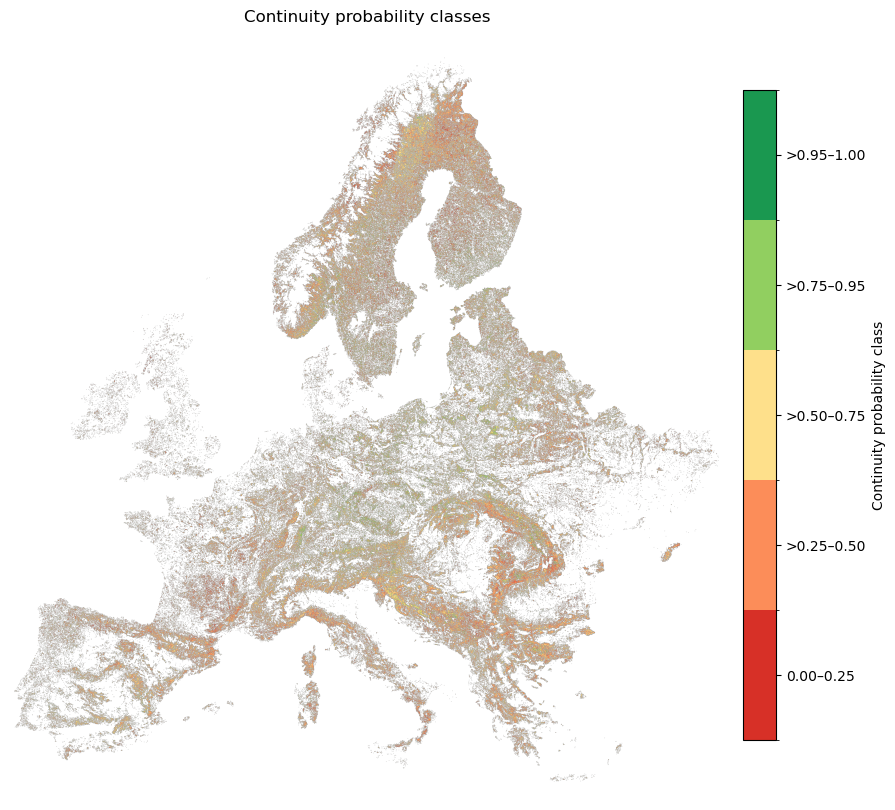

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

raster_fp = "/mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif"

# Read only a downsampled version into memory
max_size = 2500  # increase/decrease depending on RAM

with rasterio.open(raster_fp) as src:
    scale = max(src.width / max_size, src.height / max_size)

    out_width = int(src.width / scale)
    out_height = int(src.height / scale)

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=rasterio.enums.Resampling.nearest
    )

# Convert nodata class 0 to NaN for plotting
arr_plot = arr.astype("float32")
arr_plot[arr_plot == 0] = np.nan

# Discrete color map for 5 classes
cmap = ListedColormap([
    "#d73027",  # 1 very low
    "#fc8d59",  # 2 low
    "#fee08b",  # 3 moderate
    "#91cf60",  # 4 high
    "#1a9850"   # 5 very high
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

plt.figure(figsize=(12, 10))
plt.imshow(arr_plot, cmap=cmap, norm=norm)
plt.axis("off")
plt.title("Continuity probability classes")

cbar = plt.colorbar(
    ticks=[1, 2, 3, 4, 5],
    fraction=0.035,
    pad=0.02
)
cbar.ax.set_yticklabels([
    "0.00–0.25",
    ">0.25–0.50",
    ">0.50–0.75",
    ">0.75–0.95",
    ">0.95–1.00"
])
cbar.set_label("Continuity probability class")

plt.show()

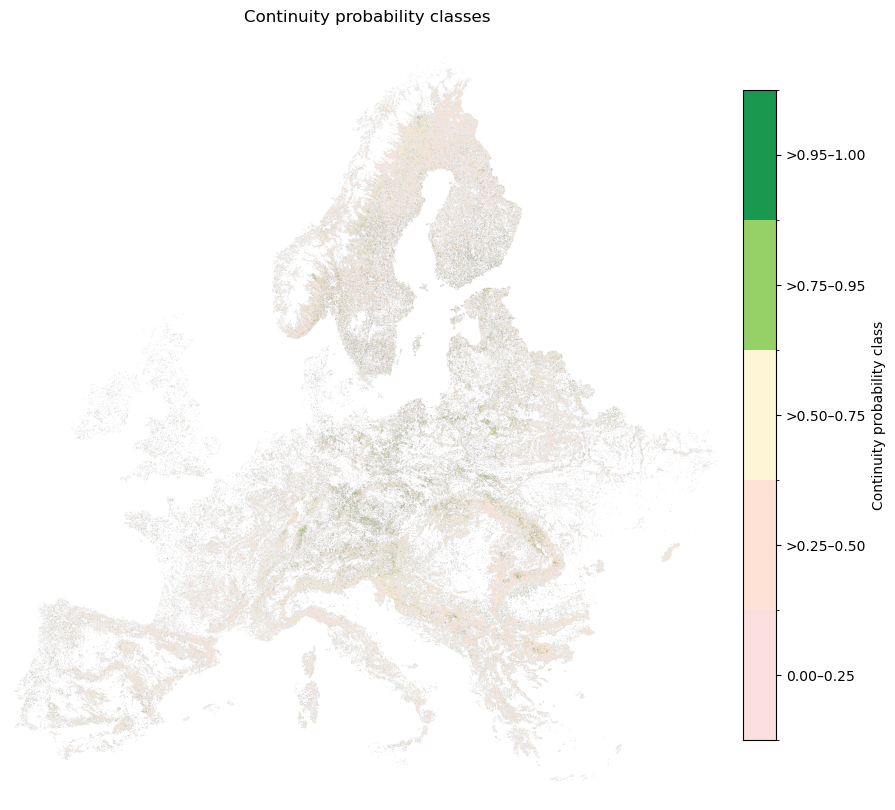

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.enums import Resampling

raster_fp = "/mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif"

# Read only a downsampled version into memory
max_size = 2500

with rasterio.open(raster_fp) as src:
    scale = max(src.width / max_size, src.height / max_size)
    out_width = int(src.width / scale)
    out_height = int(src.height / scale)

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest
    )

# Convert nodata class 0 to NaN for plotting
arr_plot = arr.astype("float32")
arr_plot[arr_plot == 0] = np.nan

# Colormap with transparency for lower-confidence classes
# RGBA = (red, green, blue, alpha)
cmap = ListedColormap([
    (215/255,  48/255,  39/255, 0.15),  # class 1 very low
    (252/255, 141/255,  89/255, 0.25),  # class 2 low
    (254/255, 224/255, 139/255, 0.35),  # class 3 moderate
    (145/255, 207/255,  96/255, 0.95),  # class 4 high
    ( 26/255, 152/255,  80/255, 1.00)   # class 5 very high
])

norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

plt.figure(figsize=(12, 10))
im = plt.imshow(arr_plot, cmap=cmap, norm=norm)
plt.axis("off")
plt.title("Continuity probability classes")

cbar = plt.colorbar(
    im,
    ticks=[1, 2, 3, 4, 5],
    fraction=0.035,
    pad=0.02
)
cbar.ax.set_yticklabels([
    "0.00–0.25",
    ">0.25–0.50",
    ">0.50–0.75",
    ">0.75–0.95",
    ">0.95–1.00"
])
cbar.set_label("Continuity probability class")

plt.show()

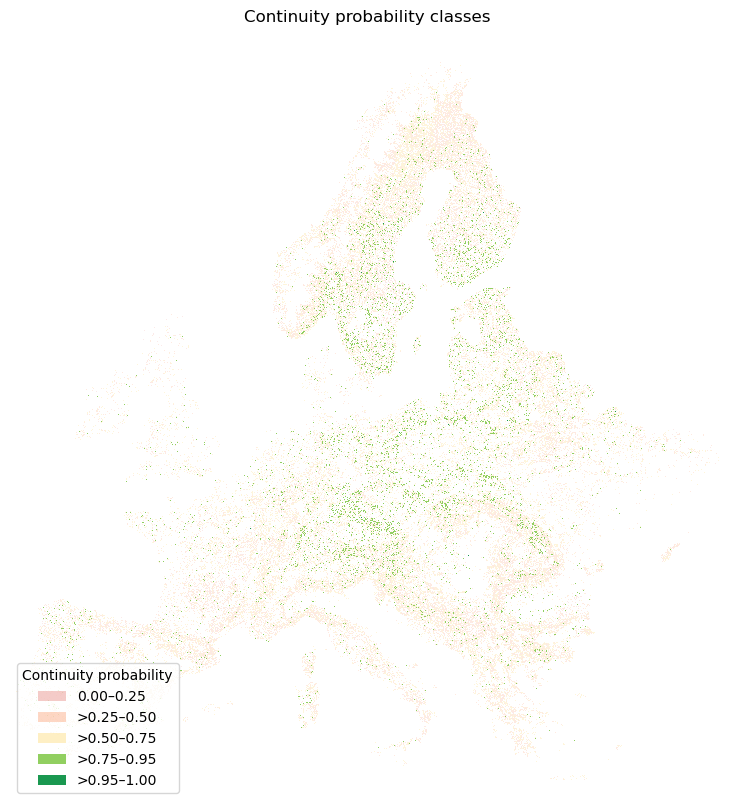

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.enums import Resampling
from matplotlib.patches import Patch

raster_fp = "/mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif"

# ------------------------------------------------------------
# Read downsampled raster
# ------------------------------------------------------------
max_size = 2500

with rasterio.open(raster_fp) as src:
    scale = max(src.width / max_size, src.height / max_size)
    out_width = int(src.width / scale)
    out_height = int(src.height / scale)

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest
    )

# ------------------------------------------------------------
# Split into low/moderate classes and high-confidence classes
# ------------------------------------------------------------

# Classes 1–3: low/moderate probability background
low = arr.astype("float32")
low[(low == 0) | (low > 3)] = np.nan

# Classes 4–5: high-confidence foreground
high = arr.astype("float32")
high[(high == 0) | (high < 4)] = np.nan

# ------------------------------------------------------------
# Colormaps
# ------------------------------------------------------------

# Low classes: pale and semi-transparent
cmap_low = ListedColormap([
    (215/255, 48/255, 39/255, 0.10),    # class 1
    (252/255, 141/255, 89/255, 0.18),   # class 2
    (254/255, 224/255, 139/255, 0.30)   # class 3
])
norm_low = BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap_low.N)

# High classes: fully opaque and strong
cmap_high = ListedColormap([
    "#91cf60",  # class 4
    "#1a9850"   # class 5
])
norm_high = BoundaryNorm([3.5, 4.5, 5.5], cmap_high.N)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(
    low,
    cmap=cmap_low,
    norm=norm_low,
    interpolation="nearest"
)

ax.imshow(
    high,
    cmap=cmap_high,
    norm=norm_high,
    interpolation="nearest"
)

ax.set_axis_off()
ax.set_title("Continuity probability classes")

# Manual legend, because we use two layers
legend_elements = [
    Patch(facecolor=(215/255, 48/255, 39/255, 0.25), label="0.00–0.25"),
    Patch(facecolor=(252/255, 141/255, 89/255, 0.35), label=">0.25–0.50"),
    Patch(facecolor=(254/255, 224/255, 139/255, 0.50), label=">0.50–0.75"),
    Patch(facecolor="#91cf60", label=">0.75–0.95"),
    Patch(facecolor="#1a9850", label=">0.95–1.00"),
]

ax.legend(
    handles=legend_elements,
    title="Continuity probability",
    loc="lower left",
    frameon=True
)

plt.show()

In [5]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

prob_fp = "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif"

# ------------------------------------------------------------
# Sample probability values block-wise
# ------------------------------------------------------------

sample_per_block = 500   # increase if you want smoother density
seed = 42
rng = np.random.default_rng(seed)

samples = []

with rasterio.open(prob_fp) as src:
    nodata = src.nodata
    windows = list(src.block_windows(1))

    for _, window in tqdm(windows, desc="Sampling raster blocks"):
        arr = src.read(1, window=window).astype("float32")

        if nodata is not None:
            valid = (arr != nodata) & np.isfinite(arr)
        else:
            valid = np.isfinite(arr)

        vals = arr[valid]

        # keep only probability values in expected range
        vals = vals[(vals >= 0) & (vals <= 1)]

        if vals.size == 0:
            continue

        n = min(sample_per_block, vals.size)
        idx = rng.choice(vals.size, size=n, replace=False)
        samples.append(vals[idx])

prob_sample = np.concatenate(samples)

print("Number of sampled pixels:", len(prob_sample))
print("Min:", np.nanmin(prob_sample))
print("Max:", np.nanmax(prob_sample))
print("Mean:", np.nanmean(prob_sample))

Sampling raster blocks:   0%|          | 0/277876 [00:00<?, ?it/s]

Number of sampled pixels: 47579232
Min: 0.01962661
Max: 0.9887121
Mean: 0.5436955


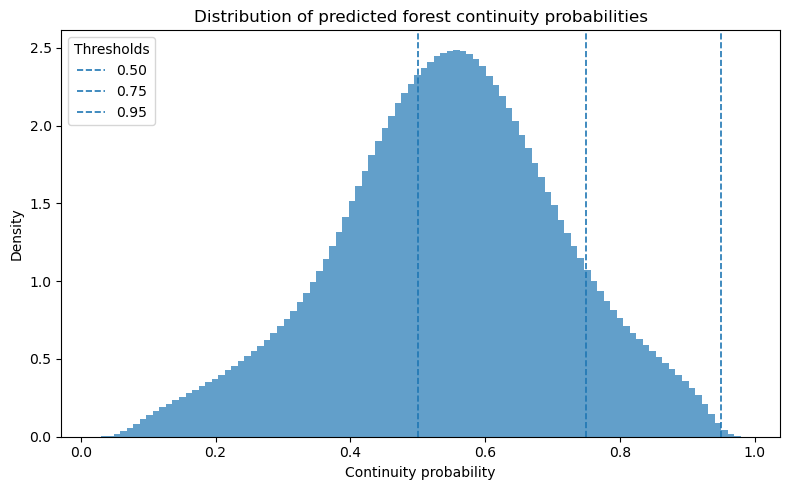

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    prob_sample,
    bins=100,
    density=True,
    alpha=0.7
)

# threshold lines
plt.axvline(0.50, linestyle="--", linewidth=1.2, label="0.50")
plt.axvline(0.75, linestyle="--", linewidth=1.2, label="0.75")
plt.axvline(0.95, linestyle="--", linewidth=1.2, label="0.95")

plt.xlabel("Continuity probability")
plt.ylabel("Density")
plt.title("Distribution of predicted forest continuity probabilities")
plt.legend(title="Thresholds")
plt.tight_layout()
plt.show()

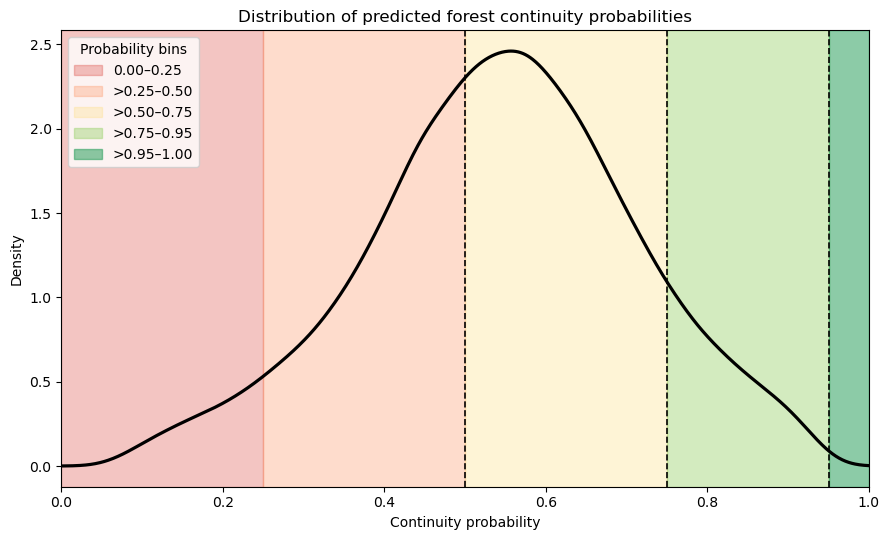

In [8]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Optional: subsample for KDE speed
# ------------------------------------------------------------
max_kde_n = 400_000
rng = np.random.default_rng(42)

if len(prob_sample) > max_kde_n:
    prob_kde = rng.choice(prob_sample, size=max_kde_n, replace=False)
else:
    prob_kde = prob_sample

# ------------------------------------------------------------
# Smooth density estimate
# Larger bw_method = smoother line
# ------------------------------------------------------------
x = np.linspace(0, 1, 1000)
kde = gaussian_kde(prob_kde, bw_method=0.12)   # try 0.15 if you want even smoother
y = kde(x)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))

# stronger shaded bins
plt.axvspan(0.00, 0.25, color="#d73027", alpha=0.28, label="0.00–0.25")
plt.axvspan(0.25, 0.50, color="#fc8d59", alpha=0.30, label=">0.25–0.50")
plt.axvspan(0.50, 0.75, color="#fee08b", alpha=0.35, label=">0.50–0.75")
plt.axvspan(0.75, 0.95, color="#91cf60", alpha=0.40, label=">0.75–0.95")
plt.axvspan(0.95, 1.00, color="#1a9850", alpha=0.50, label=">0.95–1.00")

# smooth density line
plt.plot(x, y, color="black", linewidth=2.3)

# threshold lines
plt.axvline(0.50, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0.75, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0.95, color="black", linestyle="--", linewidth=1.2)

plt.xlabel("Continuity probability")
plt.ylabel("Density")
plt.title("Distribution of predicted forest continuity probabilities")
plt.xlim(0, 1)

plt.legend(title="Probability bins", frameon=True)
plt.tight_layout()
plt.show()